In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sympy.parsing.maxima import var_name
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

from sklearn import linear_model
from sklearn.model_selection import KFold

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import re
import mne_rsa
from scipy import stats
from tqdm import tqdm
from collections import OrderedDict

In [2]:
NUM_SEEDS = 2
FEATURES = ('linear','xor_xor_xor')

LAYERS = [64,256,128,64,64,2]
TRAIN_DATASET_SIZE = 32768
TEST_DATASET_SIZE = 1024

BATCH_SIZE = 512

OP_FNS = {'and': np.logical_and, 'or': np.logical_or, 'xor': np.logical_xor}

torch.manual_seed(0)
np.random.seed(0)

# Data

In [3]:
def make_dataset(features=FEATURES, input_unit_size=16, num_samples=126, seed=123):
    np.random.seed(seed)

    inputs = np.random.binomial(1, 0.5, size=(num_samples, len(features)*input_unit_size))
    outputs = []

    for feature_i, feature_type in enumerate(features):
        input_unit = inputs[:, feature_i*input_unit_size:(feature_i+1)*input_unit_size]

        if feature_type == 'linear':
            input_unit[:, :4] =  input_unit[:, :1]
            output_unit = input_unit[:, :1]
        else:
            output_unit = np.zeros_like(input_unit[:, :1])
            def feature_val(input):
                top, left, right = [OP_FNS[op] for op in feature_type.split('_')]
                return top(left(input[0], input[1]), right(input[2], input[3]))

            for number, index in enumerate(np.random.permutation(num_samples)):
                while feature_val(input_unit[index]) != number % 2:
                    input_unit[index] = np.random.binomial(1,0.5, input_unit_size)
                output_unit[index] = feature_val(input_unit[index])

        outputs.append(output_unit)
    return {'inputs': inputs, 'labels': np.concatenate(outputs, axis=1)}


In [4]:
class Data(Dataset):
    def __init__(self, inputs, labels,device):
        self.data = torch.tensor(inputs,device=device,dtype=torch.float)
        self.target = torch.tensor(labels,device=device,dtype=torch.float)

    def __getitem__(self, index):
        x = self.data[index]
        y = self.target[index]

        return x,y

    def __len__(self):
        return len(self.data)

# Model

In [5]:
class MLP(nn.Module):
    def __init__(self, layer_sizes: list[int]):
        super(MLP, self).__init__()
        self.layer_sizes = layer_sizes
        layers = []
        for i in range(len(layer_sizes)-2):
            layer = nn.Linear(layer_sizes[i],layer_sizes[i+1])
            std = np.sqrt(2/(layer_sizes[i]+layer_sizes[i+1]))
            torch.nn.init.trunc_normal_(layer.weight,std=std,a=-2*std,b=2*std)
            layers.append((f'linear_{i}',layer))
            layers.append((f'leaky_relu_{i}',nn.LeakyReLU()))
        self.model_body = nn.Sequential(OrderedDict(layers))
        self.output = nn.Linear(layer_sizes[-2], layer_sizes[-1])
        std = np.sqrt(2/(layer_sizes[-2]+layer_sizes[-1]))
        torch.nn.init.trunc_normal_(self.output.weight,std=std,a=-2*std,b=2*std)

    def forward(self, x):
        x = self.model_body(x)
        out = self.output(x)
        return out, x


In [6]:
def load_model(model_name,seed=0):
    state_dict = torch.load(f'models/{model_name}-{seed}.pt')
    m= MLP(layer_sizes=[64, 256, 128, 64, 64, len(state_dict['output.weight'])])
    m.load_state_dict(state_dict)
    return m

# Analysis

In [7]:
def analyze_rep_var_explained(fit_reps, fit_labels, test_reps, test_labels,np_=False):
    scores = []

    if np_:
        total_var = np.sum(np.var(test_reps,axis=0))
    else:
        total_var = torch.sum(torch.var(test_reps,dim=0))


    for feat in range(fit_labels.shape[-1]):
        reg = linear_model.LinearRegression()
        reg.fit(fit_labels[:, feat:feat+1], fit_reps)
        scores.append(reg.score(test_labels[:, feat:feat+1], test_reps))

    return scores, total_var

In [8]:
def accuracy(y,labels):
    accuracy = []
    for i in range(len(y[0])):
        accuracy.append(((y[:, i] > 0) == labels[:, i]).float().mean())
    return [((y > 0) == labels).float().mean()]+accuracy

# Training

In [9]:
def run(data_features=FEATURES, train_features=None, pretrain=None, units_per_feature=16, max_epochs=50000, train_size=TRAIN_DATASET_SIZE,batch_size=BATCH_SIZE,seeds=1, device='cpu', filename='results', epsilon=0, verbose=0,record_variance=False):
    device_ = torch.device(device)
    out_features = len(train_features) if train_features else len(data_features)
    model_layers = [units_per_feature*len(data_features), 256, 128, 64, 64, out_features]

    #output file setup
    file = open(f'results/{filename}.csv',mode='w')
    features = range(len(data_features)) if train_features is None else train_features
    v_file = open(f'results/variances/{filename}_variances.csv',mode='w')
    variance_labels = ['seed','total-variance']+[f'feature{i}-{data_features[i]}' for i in features]
    v_format = ','.join(['%d']+['%.8f']*(len(variance_labels)-1))+'\n'
    v_file.write(','.join(variance_labels)+'\n')
    data_labels = ['seed', 'epoch', 'test-loss','total-acc'] + ['%s_feature%i-%s' % (stat, i,data_features[i]) for stat in ('test-acc', 'test-loss') for i in features]
    out_format = ','.join(['%d', '%d'] + ['%.8f'] * (len(data_labels) - 2))+'\n'
    file.write(','.join(data_labels)+'\n')

    models = []
    for seed in range(seeds):
        torch.manual_seed(123 + seed)
        rng = np.random.default_rng(123 + seed)

        train_data = make_dataset(features=data_features, num_samples=train_size, input_unit_size=units_per_feature, seed=123+seed)
        val_data = make_dataset(features=data_features, num_samples=TEST_DATASET_SIZE, input_unit_size=units_per_feature, seed=1234+seed)
        test_data = make_dataset(features=data_features, num_samples=TEST_DATASET_SIZE, input_unit_size=units_per_feature, seed=12345+seed)

        if train_features:
            train_data['labels'] = train_data['labels'][:, train_features]
            val_data['labels'] = val_data['labels'][:, train_features]
            test_data['labels'] = test_data['labels'][:, train_features]

        train_loader = DataLoader(Data(train_data['inputs'], train_data['labels'], device), batch_size=batch_size, shuffle=True)
        x_val = torch.tensor(val_data['inputs'],device=device, dtype=torch.float)
        #y_val = torch.tensor(val_data['labels'],device=device, dtype=torch.float)
        x_test = torch.tensor(test_data['inputs'],device=device, dtype=torch.float)
        y_test = torch.tensor(test_data['labels'],device=device, dtype=torch.float)

        model = MLP(layer_sizes=model_layers).to(device_)
        criterion = nn.BCEWithLogitsLoss(reduction='mean')
        optimizer = optim.SGD(model.parameters())

        if pretrain:
            current_feature = pretrain[0]
            feature_number = 1

        vars_ = torch.Tensor()
        for epoch in tqdm(range(max_epochs)):
            model.train()
            for inputs, labels in train_loader:
                optimizer.zero_grad()
                outputs,_ = model(inputs)
                if pretrain:
                    outputs=outputs[:,current_feature]
                    labels=labels[:,current_feature]
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            if (epoch%100 == 0) or (epoch == max_epochs-1):
                with torch.no_grad():
                    model.eval()
                    y_pred, test_reps = model(x_test)
                    test_loss= criterion(y_pred, y_test)
                    test_accuracies = accuracy(y_pred,y_test)
                    test_feature_losses = [criterion(y_pred[:,i], y_test[:,i]) for i in range(len(y_pred[0]))]

                    if record_variance:
                        vp, val_reps = model(x_val)
                        reps = torch.stack([val_reps,test_reps],dim=0)
                        vars_ = torch.cat([vars_,reps])

                outputs= (seed, epoch, test_loss, *test_accuracies, *test_feature_losses)
                file.write(out_format % outputs)
                file.flush()
                if pretrain:
                    test_loss = criterion(y_pred[:,current_feature],y_test[:,current_feature])
                if verbose and epoch%1000==0:
                    print(f'epoch {epoch} test loss {test_loss}')
                if test_loss < epsilon:
                    #if pretrain and feature_number < len(pretrain):
                    if pretrain and feature_number==1:
                        if pretrain[1] <= epoch:
                            current_feature = [0,1]
                            feature_number+=1
                            print(f'switching to feature {current_feature} at epoch {epoch}')
                    else:
                        print(f'stopping early at epoch {epoch}')
                        break
        file.flush()
        if record_variance:
            for i in range(0,len(vars_),2):
                variance_scores, total_variance = analyze_rep_var_explained(vars_[i].cpu(), val_data['labels'], vars_[i+1].cpu(), test_data['labels'])
                v_out = (seed,total_variance,*variance_scores)
                v_file.write(v_format % v_out)
        v_file.flush()
        models.append(model)
        path =f'models/{filename}-{seed}.pt'
        torch.save(model.state_dict(),path)
        print(f'seed {seed} acc: {test_accuracies[0]}, loss: {test_loss}')

    return models

# Run Models

In [40]:
run_name = 'tests/pretraintester'
m =run(data_features=['linear','xor_xor_xor'],seeds=1,max_epochs=3000,epsilon=5e-3,filename=run_name,device='cpu',units_per_feature=32,pretrain=[0,1000])

  7%|▋         | 202/3000 [00:34<08:45,  5.32it/s]

done but not switching


 10%|█         | 302/3000 [00:52<07:30,  5.99it/s]

done but not switching


 13%|█▎        | 402/3000 [01:05<04:29,  9.62it/s]

...

done but not switching


 37%|███▋      | 1102/3000 [02:24<04:12,  7.53it/s]

switching to feature [0, 1] at epoch 1100


100%|██████████| 3000/3000 [06:03<00:00,  8.26it/s]

seed 0 acc: 0.74462890625, loss: 0.3475392460823059


In [9]:
models = {}

In [ ]:
run_name = 'multitask64'
print(run_name)
models[run_name] =run(data_features=['linear','xor_xor_xor'],seeds=10,max_epochs=200000,epsilon=1e-3,filename=run_name,device='cpu',record_variance=True,units_per_feature=32)

multitask64


  6%|▌         | 11700/200000 [23:13<6:13:44,  8.40it/s]


stopping early at epoch 11700
seed 0 acc: 1.0, loss: 0.0009778272360563278


 12%|█▏        | 23500/200000 [46:27<5:48:56,  8.43it/s]


stopping early at epoch 23500
seed 1 acc: 1.0, loss: 0.0009923549368977547


 43%|████▎     | 86891/200000 [3:17:25<5:10:59,  6.06it/s]

In [20]:
run_name = 'pretrain_easy'
print(run_name)
models[run_name] =run(data_features=['linear','xor_xor_xor'],seeds=5,max_epochs=200000,epsilon=5e-3,filename=run_name,device='cpu',record_variance=True,pretrain=[0,1],units_per_feature=32)

run_name = 'pretrain_hard'
print(run_name)
models[run_name] =run(data_features=['linear','xor_xor_xor'],seeds=5,max_epochs=200000,epsilon=5e-3,filename=run_name,device='cpu',record_variance=True,pretrain=[1,0],units_per_feature=32)

pretrain_easy


  0%|          | 202/200000 [00:27<7:48:29,  7.11it/s] 

switching to feature 1 at epoch 200


  3%|▎         | 5600/200000 [13:43<7:56:16,  6.80it/s] 


stopping early at epoch 5600
seed 0 acc: 0.9970703125, loss: 0.003752383403480053


...

stopping early at epoch 8000
seed 3 acc: 0.76025390625, loss: 0.0019134663743898273


  3%|▎         | 6302/200000 [19:26<9:49:03,  5.48it/s] 

switching to feature 0 at epoch 6300


  3%|▎         | 6400/200000 [19:45<9:57:28,  5.40it/s] 


stopping early at epoch 6400
seed 4 acc: 0.75634765625, loss: 0.0028933375142514706


In [22]:
run_name = 'easy'
print(run_name)
models[run_name] =run(data_features=['linear','xor_xor_xor'],seeds=2,max_epochs=50000,epsilon=5e-3,filename=run_name,device='cpu',train_features=[0],units_per_feature=32)

run_name = 'hard'
print(run_name)
models[run_name] =run(data_features=['linear','xor_xor_xor'],seeds=2,max_epochs=50000,epsilon=5e-3,filename=run_name,device='cpu',train_features=[1],units_per_feature=32)

'''run_name = 'multiple_easy'
print(run_name)
models[run_name] =run(data_features=['linear','linear'],seeds=5,max_epochs=20000,epsilon=1e-3,filename=run_name,device='cpu')

run_name = 'multiple_hard'
print(run_name)
models[run_name] =run(data_features=['xor_xor_xor','xor_xor_xor'],seeds=5,max_epochs=20000,epsilon=1e-3,filename=run_name,device='cpu')
'''

easy


  0%|          | 200/50000 [00:40<2:46:58,  4.97it/s]


stopping early at epoch 200
seed 0 acc: 1.0, loss: 0.002190888859331608


  0%|          | 200/50000 [00:36<2:33:27,  5.41it/s]

stopping early at epoch 200
seed 1 acc: 1.0, loss: 0.002587632043287158


"run_name = 'hard'\nprint(run_name)\nmodels[run_name] =run(data_features=['linear','xor_xor_xor'],seeds=2,max_epochs=50000,epsilon=5e-3,filename=run_name,device='cpu',train_features=[1],units_per_feature=32)\n\nrun_name = 'multiple_easy'\nprint(run_name)\nmodels[run_name] =run(data_features=['linear','linear'],seeds=5,max_epochs=20000,epsilon=1e-3,filename=run_name,device='cpu')\n\nrun_name = 'multiple_hard'\nprint(run_name)\nmodels[run_name] =run(data_features=['xor_xor_xor','xor_xor_xor'],seeds=5,max_epochs=20000,epsilon=1e-3,filename=run_name,device='cpu')\n"

# Plotting

In [135]:
run_name='easy-v1'
results = pd.read_csv(f'results/{run_name}.csv')
variances = pd.read_csv(f'results/variances/{run_name}_variances.csv')

In [63]:
def label_features(features,default=True):
    if default:
        return {features[0]:'easy-0',features[1]:'hard-1'}
    names = {}
    for f in features:
        pattern = r'feature(\d+)-(.*)$'
        match = re.search(pattern,f)
        if match:
            if match.group(2)=='linear':
                names[f]=f'easy-{match.group(1)}'
                continue
            elif match.group(2)=='xor_xor_xor':
                names[f]=f'hard-{match.group(1)}'
                continue
        names[f] = f'feature-{len(names)}'
    return names


In [69]:
def plot_results(filename, epochs=30000,individual=False,fill_early_stopping=False,plot_accuracy=True,plot_variance=True,plot_loss=True):
    results = pd.read_csv(f'results/{filename}.csv')
    variances=None
    if plot_variance:
        variances = pd.read_csv(f'results/variances/{filename}_variances.csv')
        variances['epoch'] = results['epoch']
    plots=[]
    if fill_early_stopping:
        num_seeds = results['seed'].iloc[-1]+1
        for s in range(num_seeds):
            idx = results.loc[results['seed']==s,['epoch']].idxmax().item()
            e = results['epoch'].iat[idx]
            row = results.iloc[idx]
            v_row = None
            if plot_variance:
                v_row = variances.iloc[idx]
            while e < epochs:
                e+=100
                row['epoch'] = e
                results.loc[len(results)] = row
                if plot_variance:
                    v_row['epoch'] = e
                    variances.loc[len(variances)] = v_row
    if plot_loss:
        loss_features = results.filter(regex=r'^test-loss_').columns.values
        loss = results.loc[results['epoch']<=epochs,['seed','epoch',*loss_features]].rename(columns=label_features(loss_features))
        loss = loss.melt(['seed','epoch'],value_name='loss',var_name='feature')
        plots.append((loss,'loss'))

    if plot_accuracy:
        acc_features = results.filter(regex=r'^test-acc_').columns.values
        acc = results.loc[results['epoch']<=epochs,['seed','epoch',*acc_features]]
        acc= acc.rename(columns=label_features(acc_features))
        acc = acc.melt(['epoch','seed'],value_name='accuracy',var_name='feature')
        plots.append((acc,'accuracy'))

    if plot_variance:
        var_features = variances.filter(regex=r'^feature').columns.values

        for feature in var_features:
            variances[feature] = variances[feature]*variances['total-variance']
        for i in range(5):
            e = variances.loc[variances['seed']==i,['total-variance']].max().item()
            variances.loc[variances['seed']==i,var_features] = variances.loc[variances['seed']==i,var_features]/e

        rep_var = variances.loc[variances['epoch']<=epochs,['seed','epoch',*var_features]].rename(columns=label_features(var_features))
        rep_var = rep_var.melt(['seed','epoch'],value_name='variance',var_name='feature')
        plots.append((rep_var,'variance'))

    fig, ax = plt.subplots(ncols=len(plots), figsize=(len(plots)*4,4))
    for i,p in enumerate(plots):
        if individual:
            sns.lineplot(data=p[0],x='epoch',y=p[1],style='feature',hue='seed',ax=ax[i],palette='viridis')
        else:
            sns.lineplot(data=p[0],x='epoch',y=p[1],hue='feature',ax=ax[i])
        ax[i].set_ylim(-0.1,1.1)
    return ax

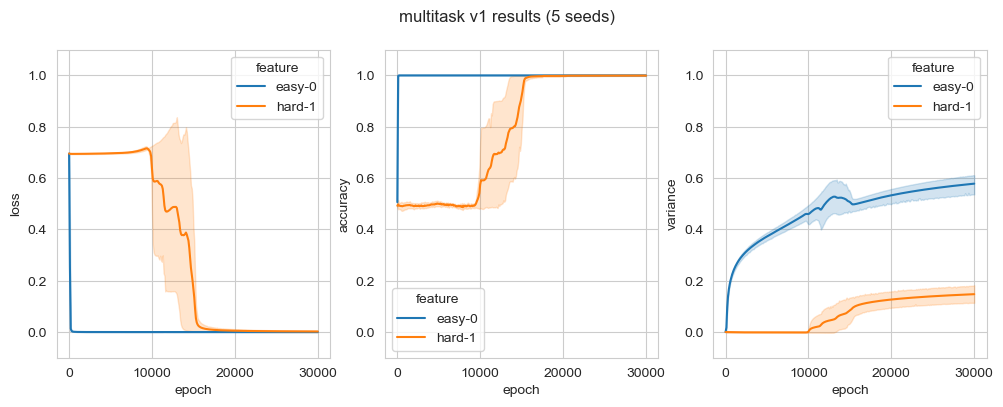

In [27]:
plot_results('multitask-v1')
plt.suptitle('multitask v1 results (5 seeds)')
plt.savefig('multitask-v1-results.png', dpi=300, bbox_inches='tight')
plt.show()

Text(0.5, 0.98, 'pretrain hard v3 results (5 seeds)')

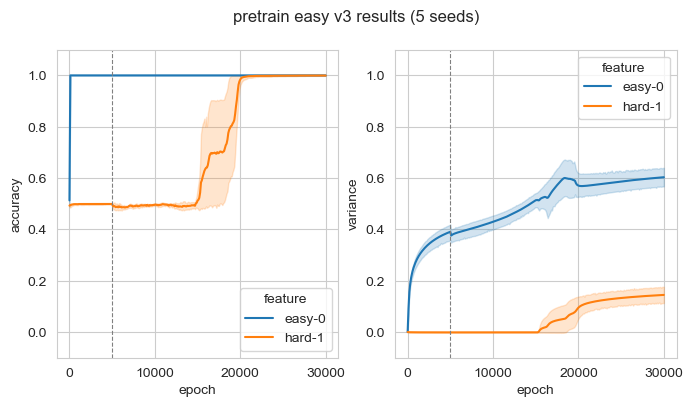

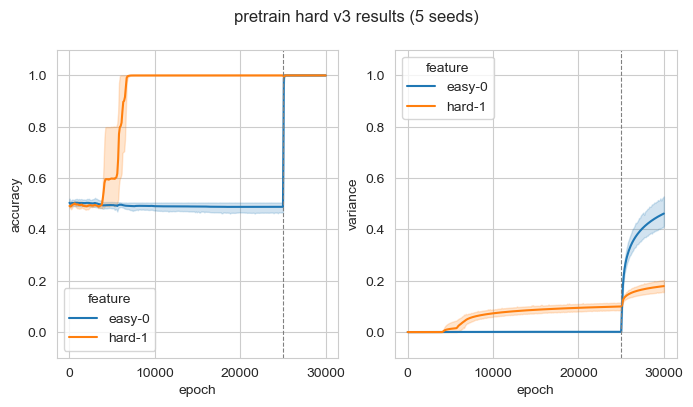

In [75]:
ax = plot_results('pretrain_easy-v3',plot_loss=False)
ax[0].axvline(x=5000,color='gray',linestyle='--',linewidth=0.8)
ax[1].axvline(x=5000,color='gray',linestyle='--',linewidth=0.8)
plt.suptitle('pretrain easy v3 results (5 seeds)')
ax=plot_results('pretrain_hard-v3',plot_loss=False)
ax[0].axvline(x=25000,color='gray',linestyle='--',linewidth=0.8)
ax[1].axvline(x=25000,color='gray',linestyle='--',linewidth=0.8)
plt.suptitle('pretrain hard v3 results (5 seeds)')

<Axes: xlabel='model', ylabel='value'>

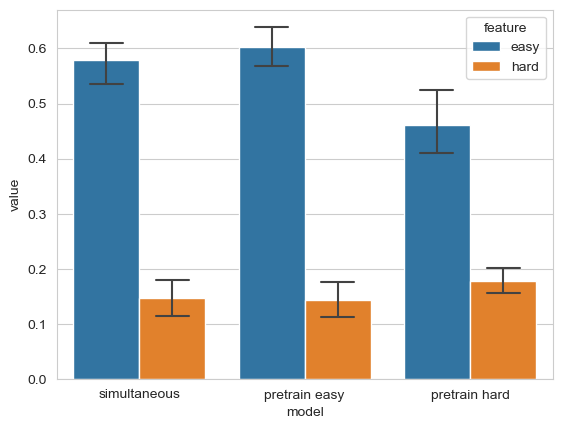

In [67]:
easy = pd.read_csv(f'results/variances/pretrain_easy-v3_variances.csv')
multi = pd.read_csv(f'results/variances/multitask-v1_variances.csv')
hard = pd.read_csv(f'results/variances/pretrain_hard-v3_variances.csv')

vars = np.zeros([3,5,2])
for i, variances in enumerate([multi,easy,hard]):
    for j in range(5):
        e = variances[variances['seed']==j].iloc[-1].loc[['feature0-linear','feature1-xor_xor_xor']]
        vars[i,j,:] = e.to_numpy()

index = pd.MultiIndex.from_product([['simultaneous','pretrain easy','pretrain hard'],range(5),['easy','hard']], names=['model','seed','feature'])
training_results=pd.DataFrame({'value': vars.flatten()}, index=index).reset_index()
sns.barplot(training_results,x='model',y='value',hue='feature',capsize=0.4,err_kws={ "linewidth": 1.5})

# RSA

In [29]:
'''def rsa(inputs, model1, model2):
    model1.eval()
    y1, reps1 = model1(inputs)
    model2.eval()
    y2, reps2 = model2(inputs)
    reps1 = reps1.cpu().detach().numpy()
    reps2 = reps2.cpu().detach().numpy()

    rdm1 = pairwise_distances(reps1,metric='euclidean')
    rdm2 = pairwise_distances(reps2,metric='euclidean')

    similarity = stats.pearsonr(np.triu(rdm1),np.triu(rdm2),axis=None)

    return similarity.correlation'''


In [68]:
'''data = make_dataset(features=['linear','xor_xor_xor'], num_samples=TEST_DATASET_SIZE, input_unit_size=32, seed=12345)
stimuli = torch.tensor(data['inputs'],device=torch.device('cpu'),dtype=torch.float)
similarities = {}

for i, a in models.items():
    similarities[i] = {}
    for j, b in models.items():
        similarities[i][j] = rsa(stimuli, a[0], b[1])'''

In [30]:
data = make_dataset(features=['linear','xor_xor_xor'], num_samples=TEST_DATASET_SIZE, input_unit_size=32, seed=789)
stimuli = torch.tensor(data['inputs'],device=torch.device('cpu'),dtype=torch.float)

In [31]:
def rdms(models,outs):
    rdms = []
    for i, model in enumerate(models):
        for s in range(4):
            m = MLP([64,256,128,64,64,outs[i]])
            m.load_state_dict(torch.load(f'models/{model}-{s}.pt'))
            m.eval()
            y, reps = m(stimuli)
            reps = reps.detach().numpy()
            rdms.append(mne_rsa.compute_rdm(reps,metric='euclidean'))
    return rdms

In [32]:
model_rdms = rdms(['easy-v1','multitask-v1','hard-v1'],[1,2,1])
rsa_vals = mne_rsa.rsa(model_rdms,model_rdms,metric='pearson')

In [33]:
mean_rsa = np.zeros([3,3])
for i in range(3):
    for j in range(3):
        mean_rsa[i,j] = np.mean(rsa_vals[4*i:(i+1)*4,4*j:(j+1)*4])


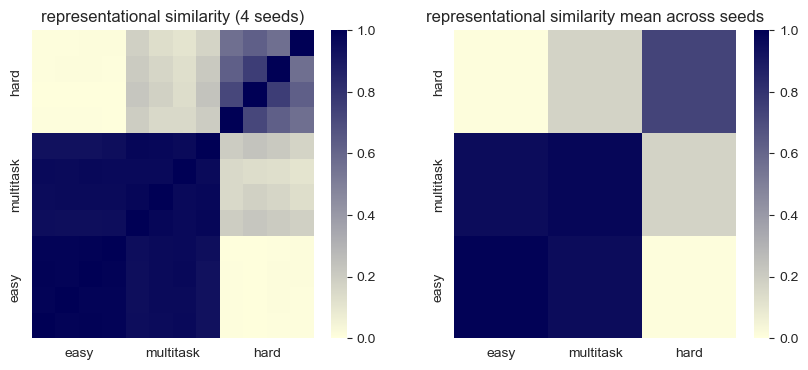

In [37]:
#df = pd.DataFrame(similarities)
#plt1 = df.loc[['hard','multitask','easy'],['easy','multitask','hard']]
#plt2 = df.loc[['multiple hard','multiple easy'],['multiple easy','multiple hard']]
model_names = ['easy','multitask','hard']
c = sns.color_palette("blend:#FFD,#005",as_cmap=True)#.reversed()
fig, axs = plt.subplots(ncols=2, figsize=(10,4))
sns.heatmap(rsa_vals,cmap=c,vmax=1,vmin=0,ax=axs[0])
sns.heatmap(mean_rsa,cmap=c,vmax=1,vmin=0,ax=axs[1],xticklabels=model_names,yticklabels=model_names)
axs[0].set_xticks(np.arange(3)*4+2, minor=False)
axs[0].set_xticklabels(model_names)
axs[0].set_yticks(np.arange(3)*4+2, minor=False)
axs[0].set_yticklabels(model_names)
axs[0].invert_yaxis()
axs[1].invert_yaxis()
axs[0].set_title('representational similarity (4 seeds)')
axs[1].set_title('representational similarity mean across seeds')
plt.savefig('rsa-v1.png',dpi=300,bbox_inches='tight')
plt.show()

# PCA

In [10]:
def to_pcs_(activations,n_components=None):
    X = activations.detach().numpy()
    U, S, Vt = np.linalg.svd(X,full_matrices=False)
    exp_var = (S**2)/(2*TEST_DATASET_SIZE-1)
    tot = np.sum(exp_var)
    percent_var = exp_var/tot
    pcs = U*S
    if n_components:
        return pcs[:,n_components],percent_var
    return pcs,percent_var

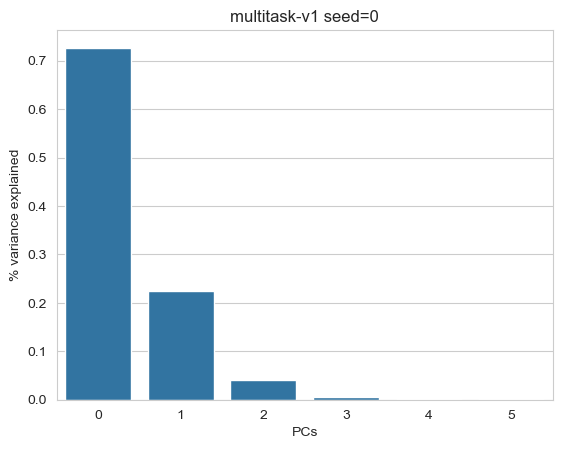

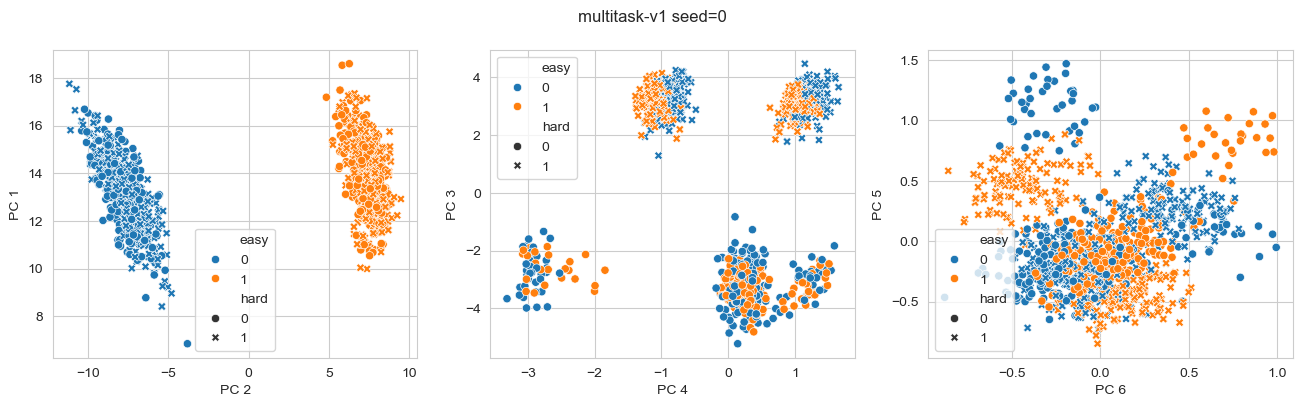

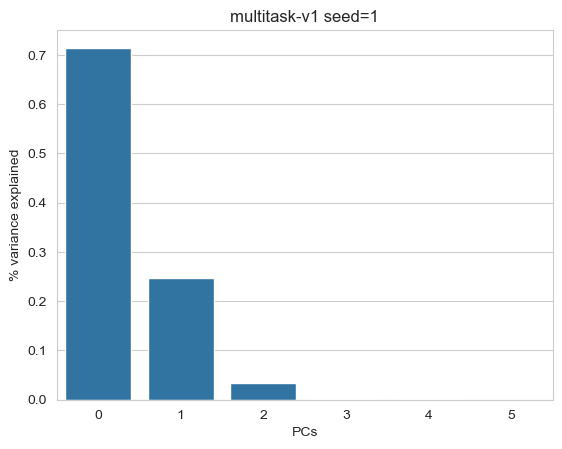

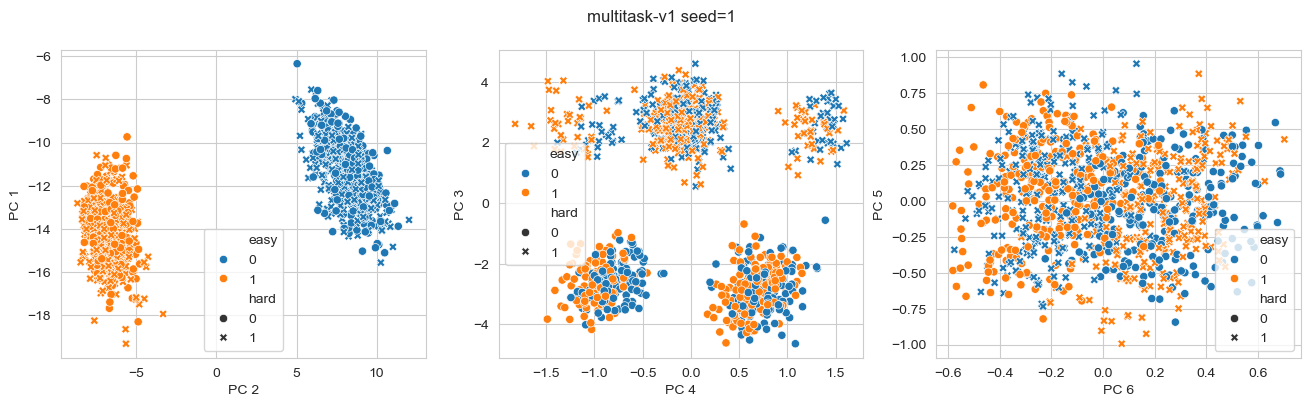

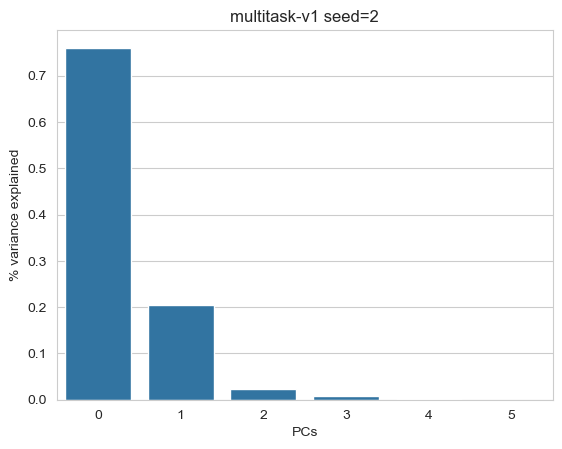

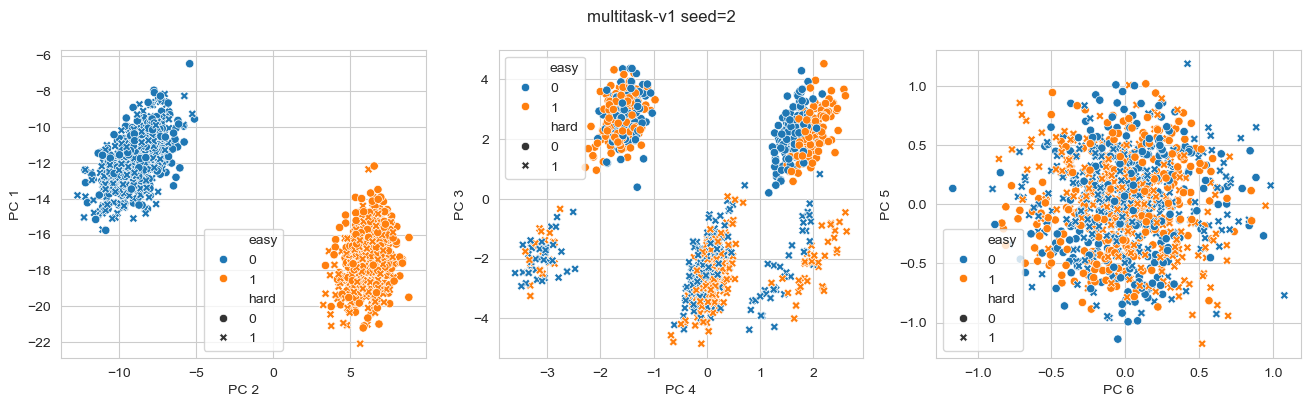

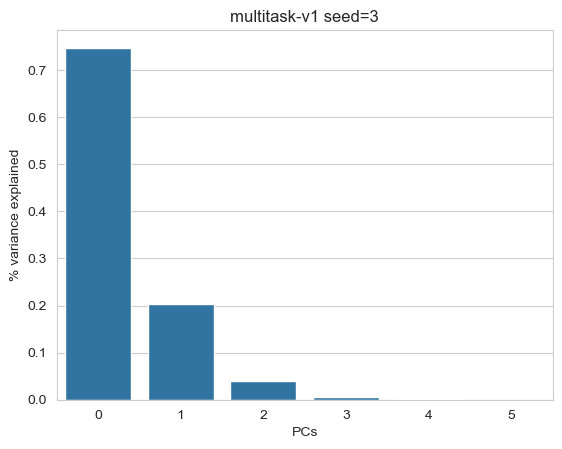

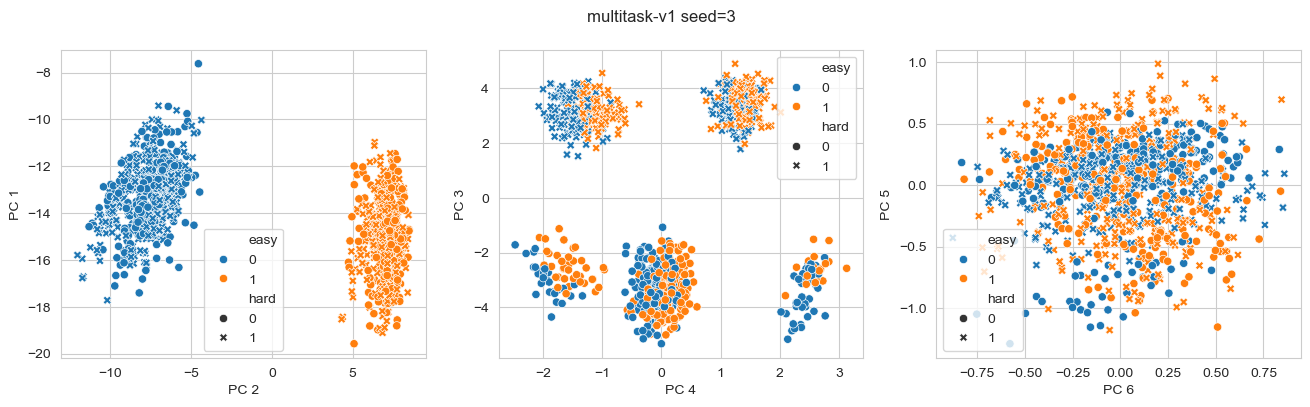

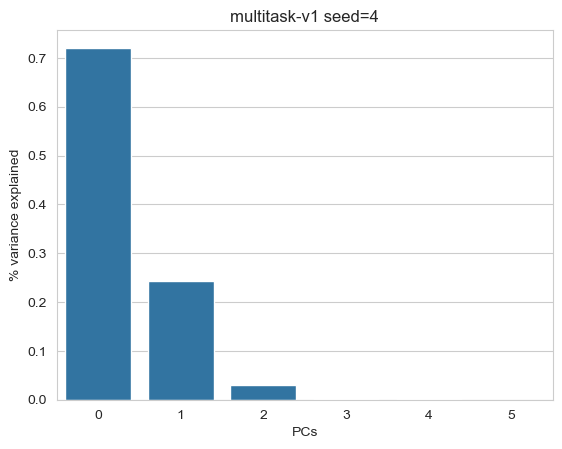

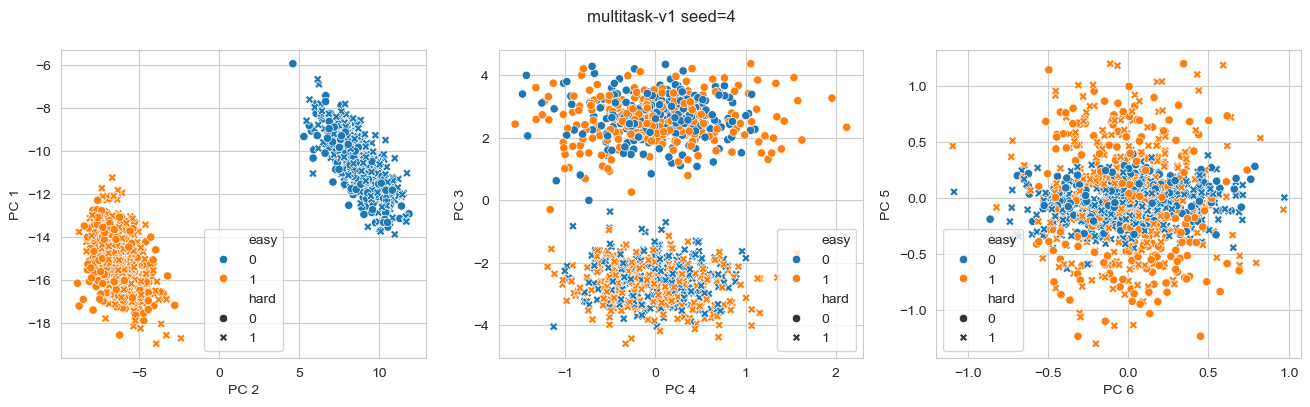

In [36]:
model='multitask-v1'
seeds = range(5)

for seed in seeds:
    data = make_dataset(features=['linear', 'xor_xor_xor'], num_samples=TEST_DATASET_SIZE, input_unit_size=32, seed=77)
    x = torch.tensor(data['inputs'],dtype=torch.float)
    m = load_model(model,seed=seed)
    m.eval()
    outputs,activations = m(x)
    pcs,correlations =to_pcs_(activations)

    pcs = pd.DataFrame(pcs,columns=[f'PC {i+1}'for i in range(len(pcs[0]))])
    pcs['easy'] = data['labels'][:,0]
    pcs['hard'] = data['labels'][:,1]

    #plt.subplots(figsize=(10,4))
    ax=sns.barplot(correlations,)
    ax.set_xlim(-0.5,5.5)
    ax.set_xlabel('PCs')
    ax.set_ylabel('% variance explained')
    ax.set_title(f'{model} seed={seed}')
    #plt.savefig(f'{model}-{seed}-pca-variance.png',dpi=300,bbox_inches='tight')
    plt.show()

    fig, axs = plt.subplots(ncols=3,figsize=(16,4))
    sns.scatterplot(data=pcs,x='PC 2',y='PC 1',hue='easy',style='hard',ax=axs[0])
    sns.scatterplot(data=pcs,x='PC 4',y='PC 3',hue='easy',style='hard',ax=axs[1])
    sns.scatterplot(data=pcs,x='PC 6',y='PC 5',hue='easy',style='hard',ax=axs[2])
    plt.suptitle(f'{model} seed={seed}')
    #plt.savefig(f'{model}-{seed}-pcas.png',dpi=300,bbox_inches='tight')
    plt.show()


<Axes: xlabel='5', ylabel='4'>

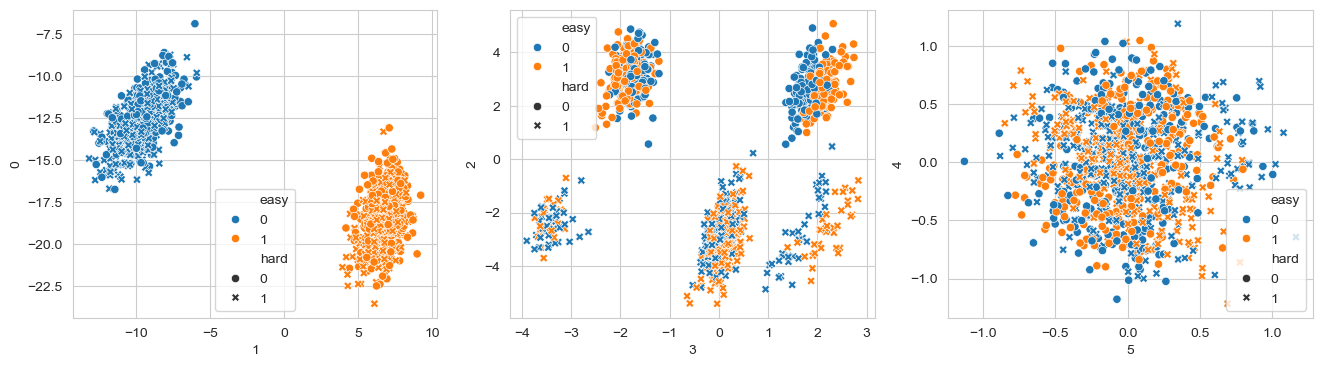

In [18]:
fig, axs = plt.subplots(ncols=3,figsize=(16,4))
sns.scatterplot(data=pcs,x=1,y=0,hue='easy',style='hard',ax=axs[0])
sns.scatterplot(data=pcs,x=3,y=2,hue='easy',style='hard',ax=axs[1])
sns.scatterplot(data=pcs,x=5,y=4,hue='easy',style='hard',ax=axs[2])


# Neural Predictivity

In [11]:
def predict(activation1, activation2,activations1_test,activation2_test):
    reg = linear_model.LinearRegression()
    reg.fit(activation1, activation2)
    pred = reg.predict(activations1_test)
    corr_scores = stats.pearsonr(pred,activation2_test).correlation
    reg_score = reg.score(activations1_test, activation2_test)
    return corr_scores, reg_score

In [12]:
def predict_cv(x,y,folds=5):
    scores = []
    correlations = []
    kf = KFold(n_splits=folds)
    for train_index, test_index in kf.split(x, y):
        corr, reg = predict(x[train_index],y[train_index],x[test_index],y[test_index])
        correlations.append(corr)
        scores.append(reg)

    return np.mean(correlations,axis=0), scores


In [13]:
data = make_dataset(features=['linear','xor_xor_xor'], num_samples=5*TEST_DATASET_SIZE, input_unit_size=32, seed=78)
x = torch.tensor(data['inputs'],dtype=torch.float)
#data2 = make_dataset(features=['linear','xor_xor_xor'], num_samples=TEST_DATASET_SIZE, input_unit_size=32, seed=90)
#x2 = torch.tensor(data2['inputs'],dtype=torch.float)

In [14]:
def compare_models(model_list,seeds,with_pca=False):
    models = {}
    scores = {}
    correlations = {}
    for modelname in model_list:
        models[modelname] = []
        for i in range(seeds):
            state_dict = torch.load(f'models/{modelname}-{i}.pt')
            m= MLP(layer_sizes=[64, 256, 128, 64, 64, len(state_dict['output.weight'])])
            m.load_state_dict(state_dict)
            models[modelname].append(m)

    for name1, model1 in models.items():
        scores[name1] = {}
        correlations[name1] = {}
        for name2, model2 in models.items():
            scores[name1][f'{name2}*'] = np.zeros([seeds,seeds])
            correlations[name1][f'{name2}*'] = [[] for i in range(seeds)]
            for i in range(seeds):
                for j in range(seeds):
                    #fitx = model1[i](x)[1].detach()
                    #testx =model1[i](x2)[1].detach()
                    #fity = model2[j](x)[1].detach()
                    #testy = model2[j](x2)[1].detach()

                    in_activations = model1[i](x)[1].detach()
                    out_activations = model2[i](x)[1].detach()

                    if with_pca:
                        #fity,_ = to_pcs_(fity,n_components=n)
                        #testy,_ = to_pcs_(testy,n_components=n)
                        out_activations,_ = to_pcs_(out_activations)

                    c, s= predict_cv(in_activations,out_activations)
                    correlations[name1][f'{name2}*'][i].append(c)
                    scores[name1][f'{name2}*'][i,j]=np.mean(s)
                    #scores[name1][f'{name2}*'][i,j]=predict(fitx,fity,testx,testy)
    return correlations,scores


In [15]:
models = ['easy-v1','multitask64','hard-v1']
corr,_ = compare_models(models,seeds=4,with_pca=True)

In [47]:
index = pd.MultiIndex.from_product([models,models,range(4),range(4),range(64)], names=['model1','model2','seed1','seed2','component'])
corr_data = pd.DataFrame({'value': np.array([list(d.values()) for d in corr.values()]).flatten()}, index=index).reset_index()

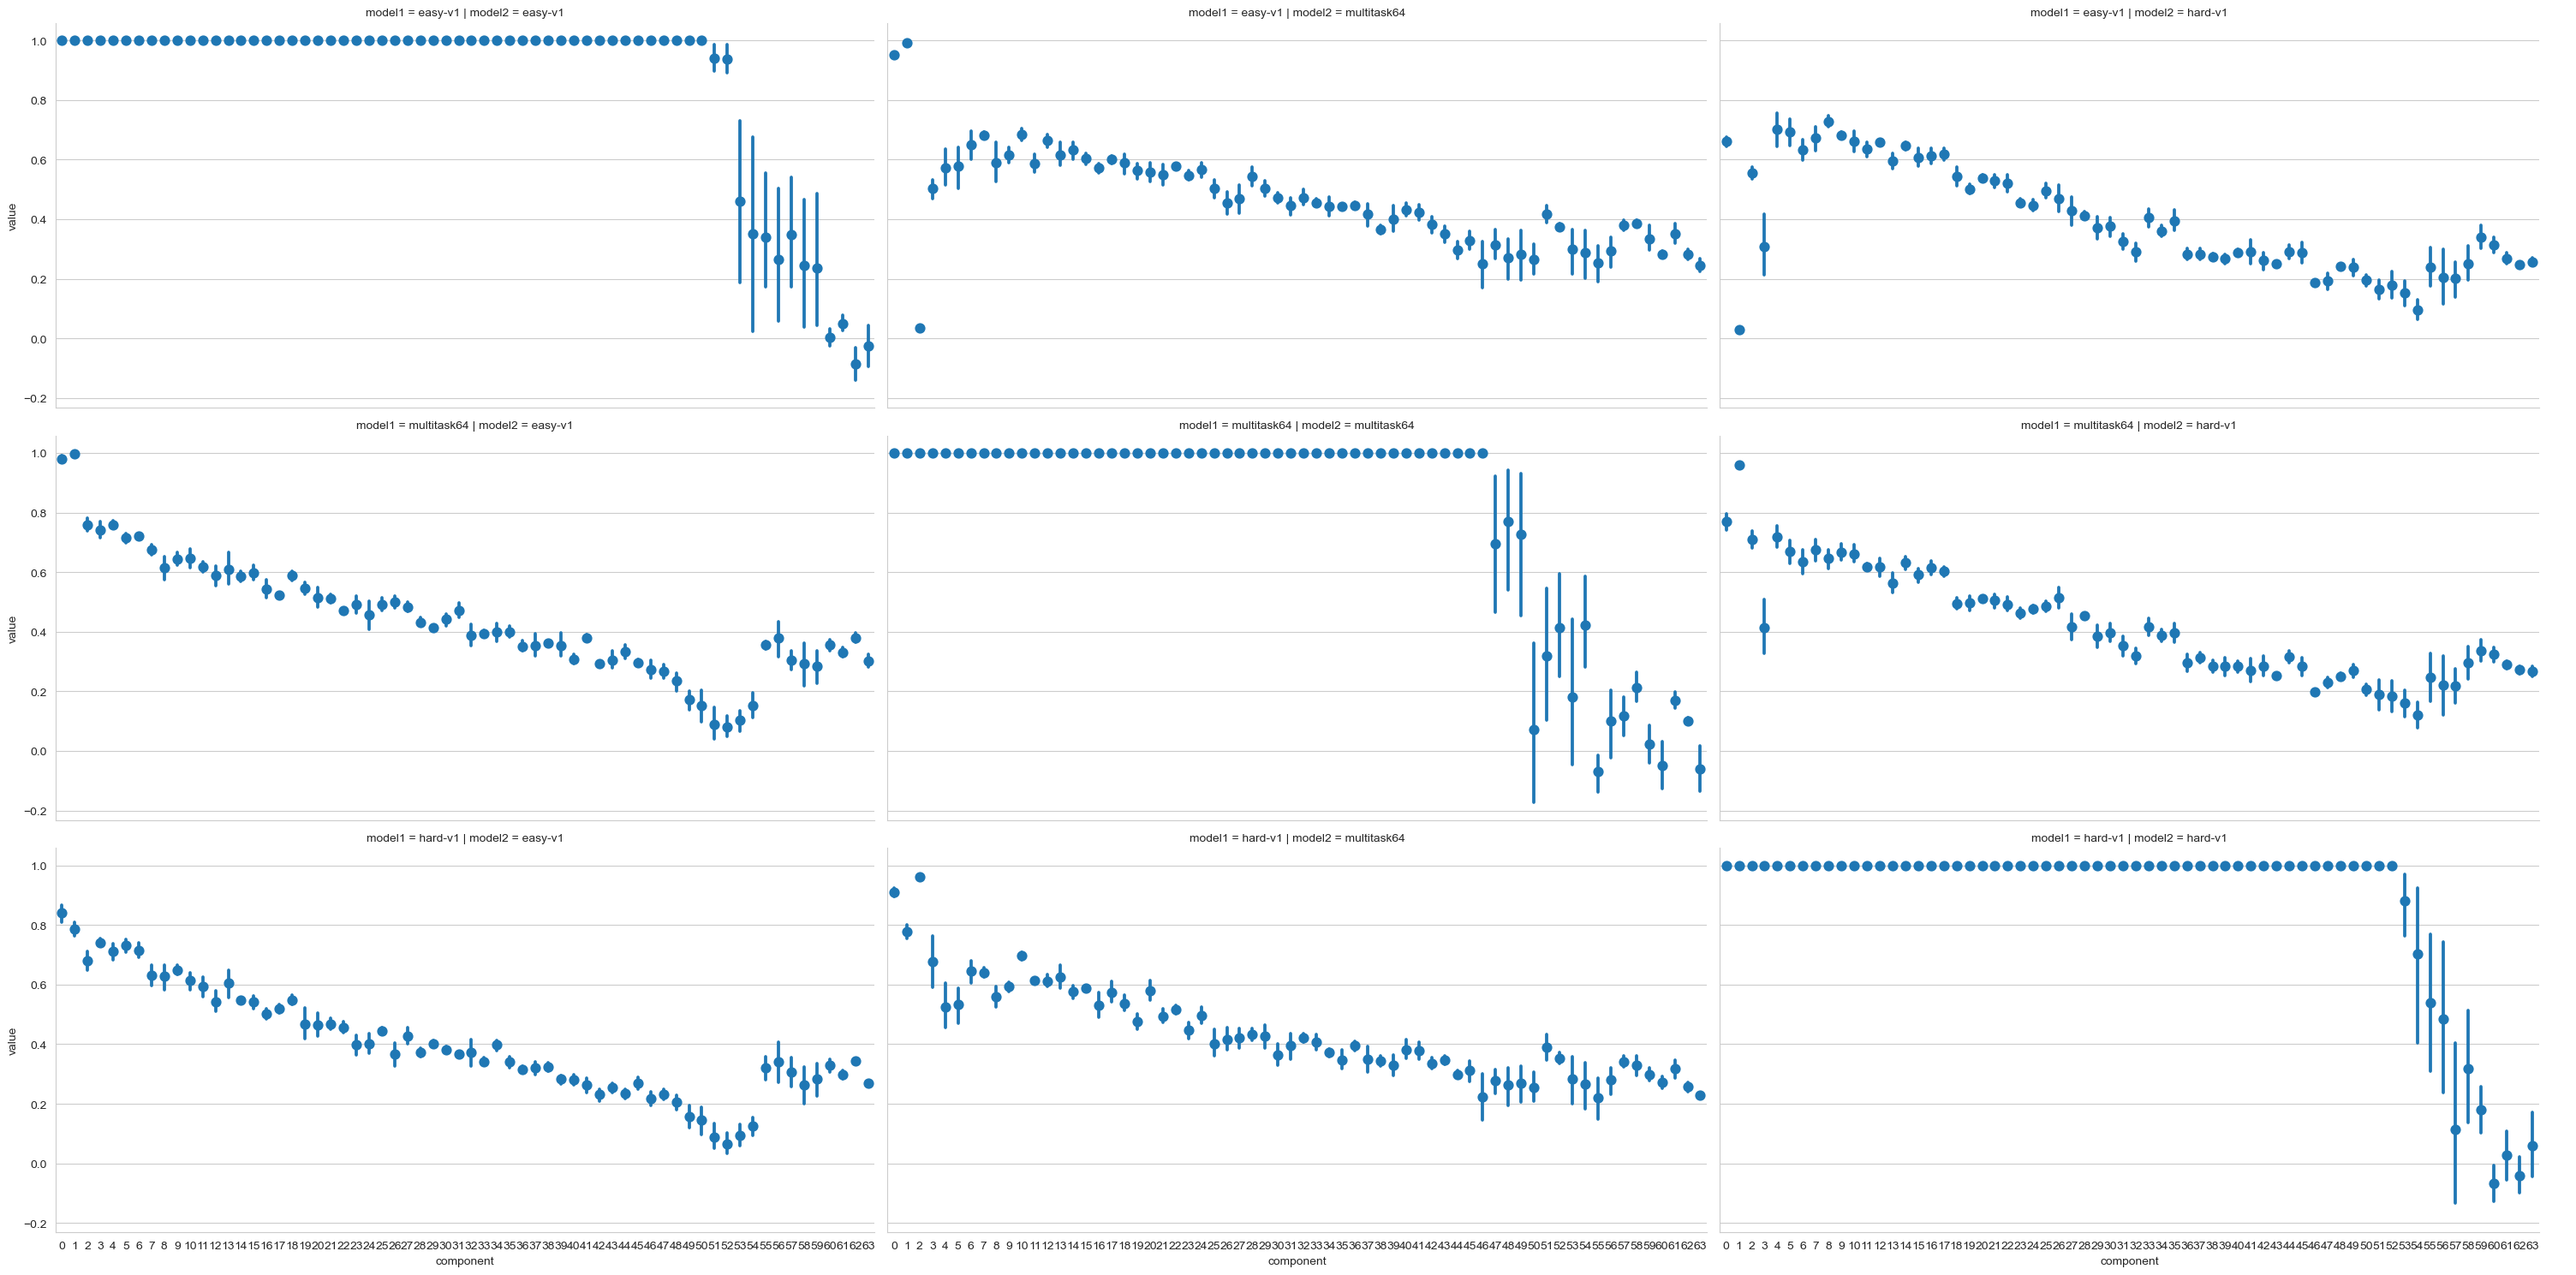

In [62]:
sns.catplot(data=corr_data, x="component", y="value", col="model2",row='model1',kind='point',aspect=2,linestyle='none')
plt.savefig('pc_correlations.png',dpi=300,bbox_inches='tight')
plt.show()

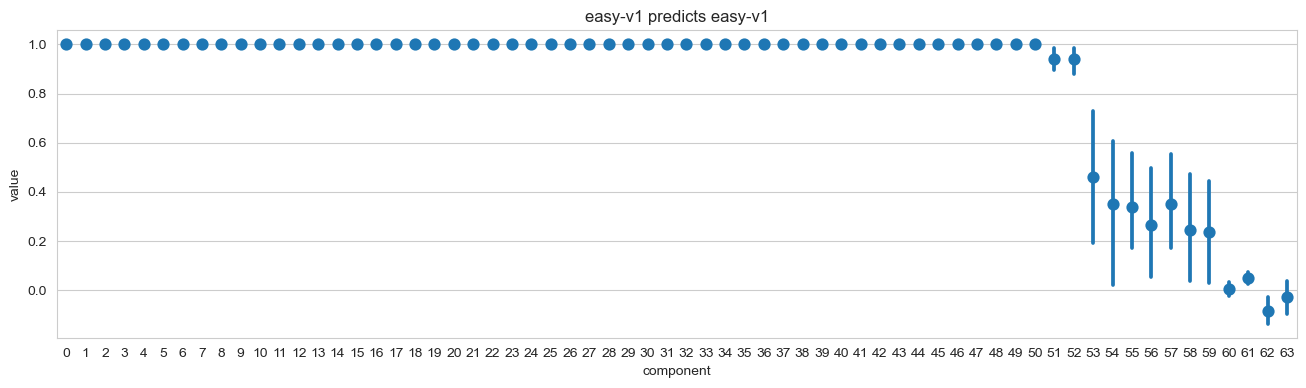

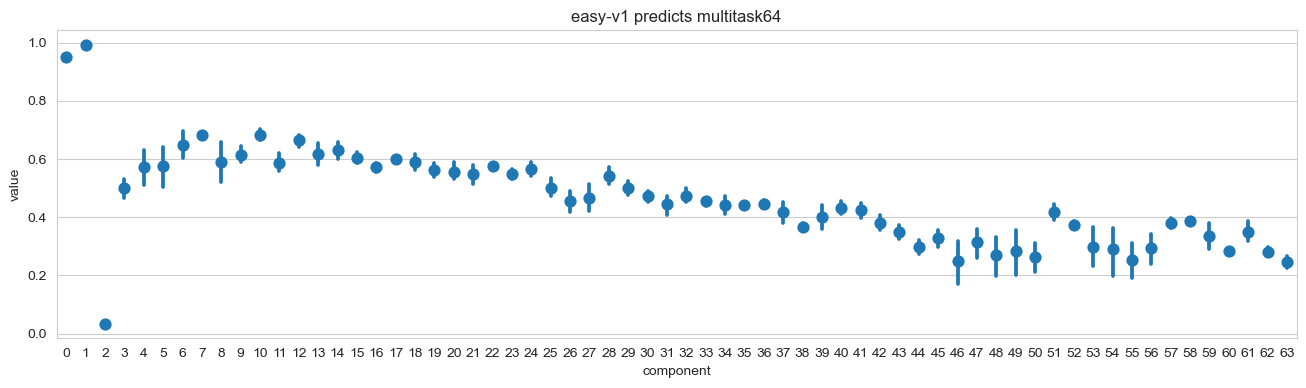

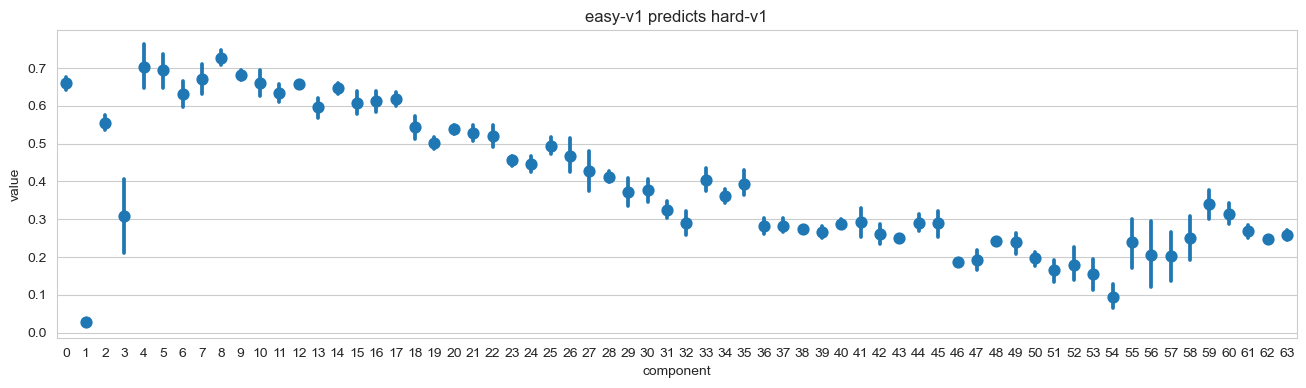

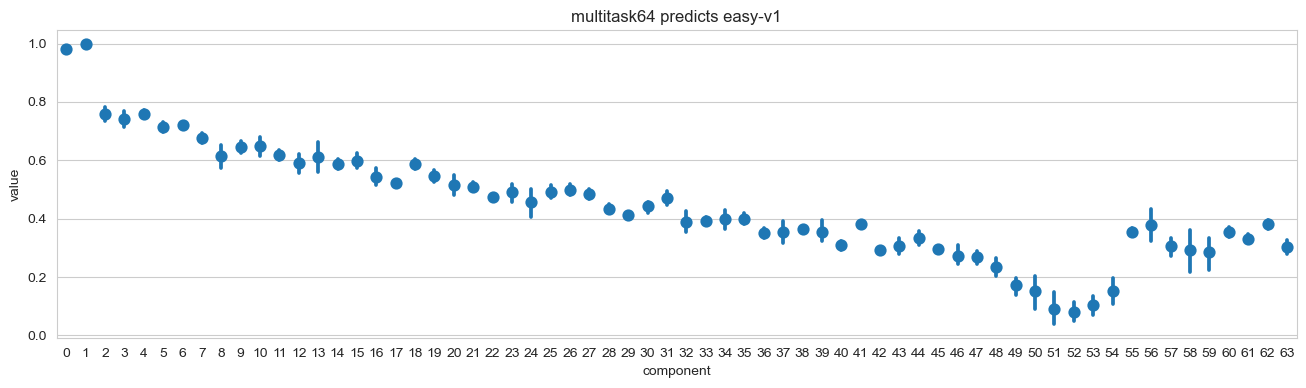

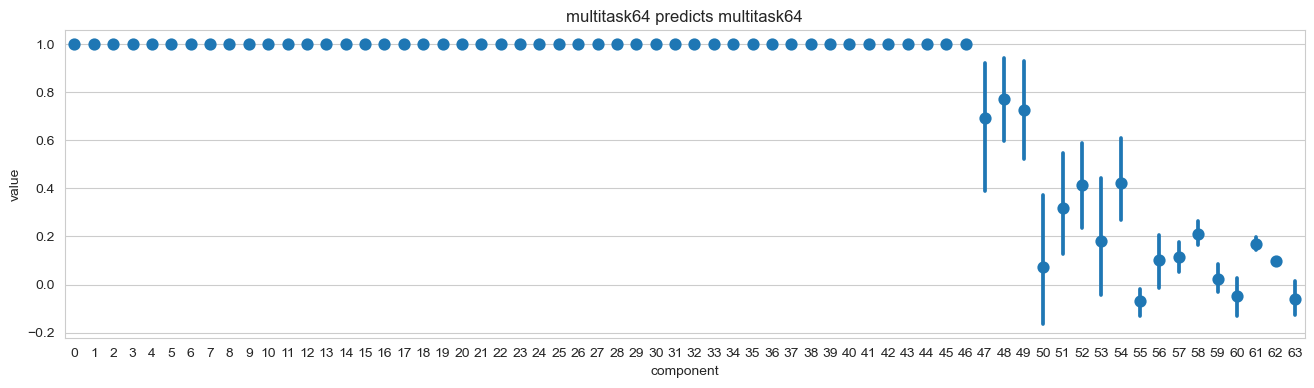

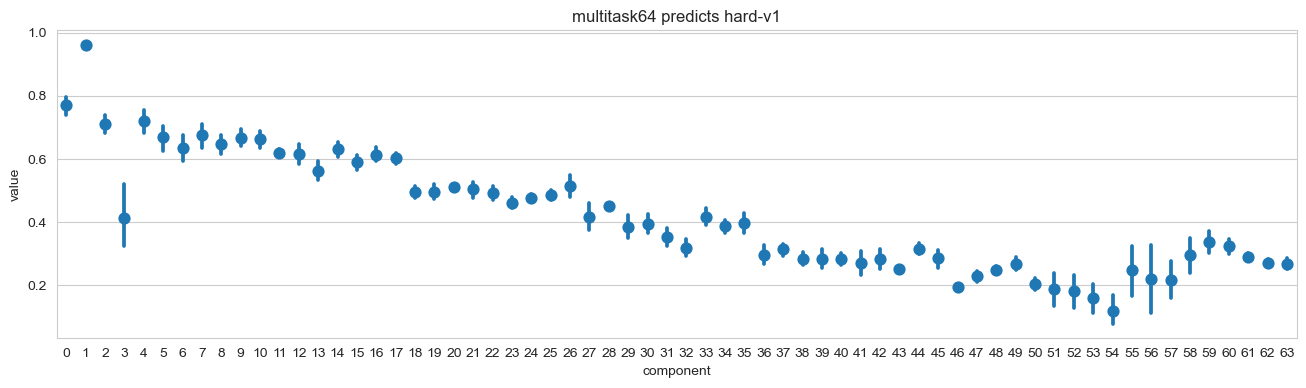

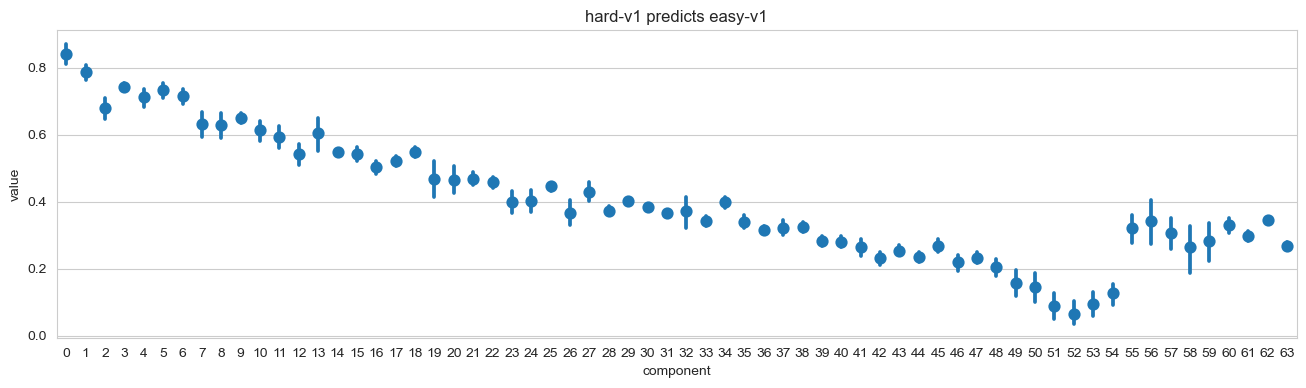

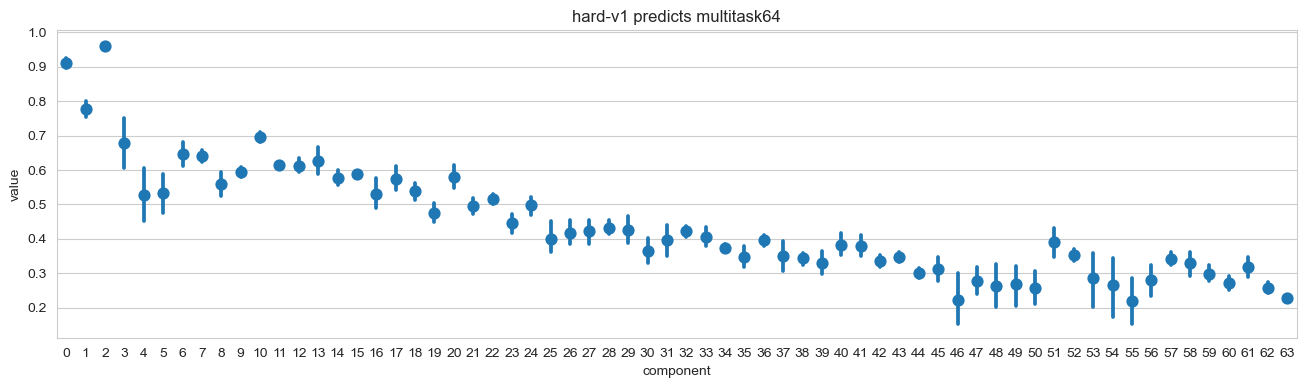

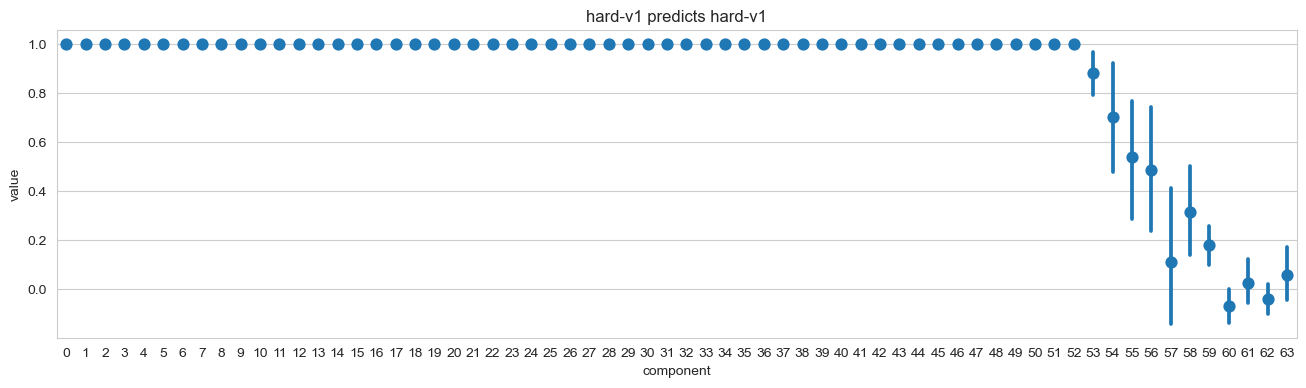

In [50]:
for model1 in models:
    for model2 in models:
        c= corr_data[(corr_data['model1']==model1)&(corr_data['model2']==model2)]
        fig, ax = plt.subplots(figsize=(16,4))
        sns.pointplot(c,y='value',x='component',ax=ax,linestyles='none')
        ax.set_title(f'{model1} predicts {model2}')

In [15]:
models = ['easy-v1','multitask64','hard-v1']
_,scores = compare_models(models,seeds=4)
scores = pd.DataFrame(scores).explode(models).apply(lambda x:  [v for lst in x for v in lst], axis=1, result_type="expand")

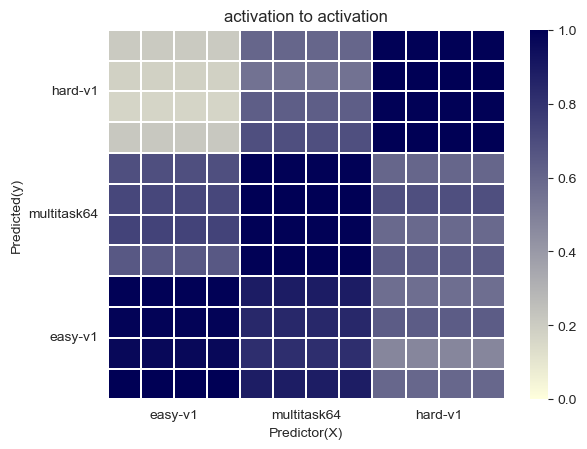

In [16]:
c = sns.color_palette("blend:#FFD,#005",as_cmap=True)
ax=sns.heatmap(scores,cmap=c,vmin=0,vmax=1,linewidths=0.01)

ax.set(xlabel='Predictor(X)',ylabel='Predicted(y)',title='activation to activation')
ax.invert_yaxis()
ax.set_xticks(np.arange(3)*4+2, minor=False)
ax.set_xticklabels(models)
ax.set_yticks(np.arange(3)*4+2, minor=False)
ax.set_yticklabels(models)
plt.savefig('model_prediction_heatmap.png',dpi=300,bbox_inches='tight')
plt.show()